In [ ]:
# === Colab bootstrap (no-op when running locally) ===========================
# Clones the repo into /content/tesina, pip-installs requirements, and
# switches the working directory to .../tesina/notebooks so the existing
# `sys.path.insert(0, '..')` import block below resolves correctly.
import os, sys, subprocess, pathlib

def _in_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False

if _in_colab():
    REPO_URL = "https://github.com/ncapac/tesina.git"
    REPO_DIR = "/content/tesina"
    if not pathlib.Path(REPO_DIR).is_dir():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(f"{REPO_DIR}/notebooks")
    try:
        import equinox  # noqa: F401
    except ImportError:
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", "-r",
             f"{REPO_DIR}/requirements.txt"],
            check=True,
        )
    # Raw data is gitignored; warn (don't error — the next cell will fail loudly).
    needed = ["data/power_data.p", "data/nwp_data.h5",
              "data/clusters.csv", "data/daily_covariates.csv",
              "data/scale_stats.json"]
    missing = [f for f in needed if not pathlib.Path(REPO_DIR, f).exists()]
    if missing:
        print("[bootstrap] WARNING — upload these to /content/tesina/data/ "
              "(via the file panel, gdown, or Drive mount) before continuing:")
        for f in missing:
            print(f"           - {f}")
    else:
        print("[bootstrap] Colab env ready — repo + deps + data all present.")


[bootstrap] WARNING — upload these to /content/tesina/data/ (via the file panel, gdown, or Drive mount) before continuing:
           - data/power_data.p


# 03a — Diffusion model training

Train `DiffusionTransformer1D` on the Rolle daily instances using the locked
conditioning design from notebook 02 §8b.1:

```
c_discrete   = [cluster_id, day_type, season]            # 3 channels, AdaLN
c_continuous = [temp_normed, log_mean_z, log_std_z]      # 3 channels, cross-attention
```

Data loading, train/val split, and the sanity-panel layout are identical to
[03_benchmark.ipynb](03_benchmark.ipynb) so the resulting metrics are
directly comparable to the historical baseline floor (val MAE ≈ 15.4 kW).


In [ ]:
import sys, os, pathlib, json
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import jax, jax.numpy as jnp, equinox as eqx

from src.data.loader   import load_rolle_data, compute_temp_stats, normalize_temp
from src.data.dataset  import (make_daily_instances, train_val_split_instances,
                               numpy_dataloader)
from src.models.diffusion     import DiffusionProcess
from src.models.transformer1d import DiffusionTransformer1D
from src.training.train       import Trainer
from src.runtime_paths        import DATA_DIR, OUTPUT_DIR

# ----- Runtime profile ---------------------------------------------------
# Toggle GPU=True on Colab / a real accelerator for a full training run.
# GPU=False is a fast sanity check that still exercises every code path.
GPU = bool(int(os.environ.get("TESINA_GPU", "0")))
try:
    _dev0 = jax.devices()[0].platform
except Exception:
    _dev0 = "cpu"
if not GPU and _dev0 in ("gpu", "tpu"):
    GPU = True   # auto-upgrade when an accelerator is actually present
print(f"[runtime] jax device = {_dev0!r}  GPU profile = {GPU}")

RANDOM_SEED  = 42
VAL_FRACTION = 0.15
BATCH_SIZE   = 128 if GPU else 64


[runtime] jax device = 'gpu'  GPU profile = True


## 1. Load data and the locked 6-channel conditioning vector

Mirror of `03_benchmark.ipynb` §1 — merges `clusters.csv` and
`daily_covariates.csv` into the dataset returned by `make_daily_instances`.


In [ ]:
# === Data: download missing raw files from Zenodo (Colab only) =============
# On Colab the git-cloned repo has the derived artefacts (clusters.csv etc.)
# but NOT the raw Zenodo files (power_data.p, nwp_data.h5) since they are
# gitignored.  This cell fetches only the missing ones via the Zenodo REST API.
# Files are open-access (CC-BY-4.0, DOI 10.5281/zenodo.3463137).
# No-op when running locally (files already present).

import pathlib, subprocess

def _in_colab():
    try:
        import google.colab; return True
    except ImportError:
        return False

ZENODO_FILES = {
    "power_data.p" : "https://zenodo.org/api/records/3463137/files/power_data.p/content",
    "nwp_data.h5"  : "https://zenodo.org/api/records/3463137/files/nwp_data.h5/content",
}
_MB = {"power_data.p": 171, "nwp_data.h5": 70}

if _in_colab():
    REPO_DATA = pathlib.Path("/content/tesina/data")
    REPO_DATA.mkdir(parents=True, exist_ok=True)
    for fname, url in ZENODO_FILES.items():
        dst = REPO_DATA / fname
        if dst.exists():
            print(f"  ok  {fname} already present ({dst.stat().st_size / 1e6:.0f} MB) — skipping")
        else:
            print(f"  dl  {fname} from Zenodo (~{_MB[fname]} MB) ...")
            result = subprocess.run(["wget", "-q", "--show-progress", "-O", str(dst), url])
            if result.returncode == 0:
                print(f"  ok  {fname} saved ({dst.stat().st_size / 1e6:.0f} MB)")
            else:
                print(f"  FAIL  download failed for {fname} (exit {result.returncode})")
else:
    print("Local environment — skipping Zenodo download.")


  dl  power_data.p from Zenodo (~171 MB) ...
  ok  power_data.p saved (179 MB)
  ok  nwp_data.h5 already present (73 MB) — skipping


In [ ]:
from src.data.dataset import shape_normalize, split_mask_by_meter
from src.data.loader  import invert_scale_z
import json as _json

power_df, temp_daily = load_rolle_data(DATA_DIR)
temp_stats  = compute_temp_stats(temp_daily)
temp_normed = normalize_temp(temp_daily, temp_stats)

df_cl  = pd.read_csv(pathlib.Path(DATA_DIR) / 'clusters.csv')
df_cov = pd.read_csv(pathlib.Path(DATA_DIR) / 'daily_covariates.csv')
cl_lookup  = {(int(r.meter_id), r.date): int(r.cluster_id)
              for _, r in df_cl.iterrows()}
cov_lookup = {(int(r.meter_id), r.date):
              (float(r.temp_normed), float(r.log_mean_z), float(r.log_std_z))
              for _, r in df_cov.iterrows()}

# Scale stats (saved by notebook 02 §9) — needed to invert the global z-score
# applied to log_mean / log_std, which in turn allows shape_denormalize() to
# map generated profiles back to Watts at evaluation time.
scale_stats = _json.loads((pathlib.Path(DATA_DIR) / 'scale_stats.json').read_text())

xs, c_disc, c_cont1, dates, meter_ids = make_daily_instances(
    power_df, temp_normed, cluster_labels=cl_lookup
)

# Per-instance shape normalisation (see notebook 01 §9 for rationale): the
# model learns scale-free shape; raw amplitude is recovered at inference
# from the (log_mean_z, log_std_z) channels of c_continuous.
xs, log_mean, log_std = shape_normalize(xs)

# Build the 3-channel continuous conditioning, aligned to instance order.
c_cont = np.zeros((len(xs), 3), dtype=np.float32)
for i, (m, d) in enumerate(zip(meter_ids, dates)):
    c_cont[i] = cov_lookup[(int(m), str(d))]

N_METERS   = int(meter_ids.max()) + 1
N_CLUSTERS = int(c_disc[:, 0].max()) + 1
print(f'Instances        : {len(xs):,}')
print(f'c_discrete shape : {c_disc.shape}  (cluster_id, day_type, season)')
print(f'c_continuous     : {c_cont.shape}  (temp_normed, log_mean_z, log_std_z)')
print(f'xs (normalised)  : {xs.shape}  '
      f'mean={xs.mean():+.2e}  std={xs.std():.3f}')
print(f'N_CLUSTERS       : {N_CLUSTERS}   N_METERS: {N_METERS}')

# Local-profile subsample: keeps the smoke test fast on CPU but still
# covers all clusters/seasons. Skipped under the GPU profile. The
# per-instance scales (log_mean, log_std) are subsampled in lock-step so
# they remain aligned with the surviving xs rows.
if not GPU:
    SUBSAMPLE_N = 1_000
    rng = np.random.default_rng(RANDOM_SEED)
    idx = rng.choice(len(xs), size=min(SUBSAMPLE_N, len(xs)), replace=False)
    xs, c_disc, c_cont = xs[idx], c_disc[idx], c_cont[idx]
    dates, meter_ids   = dates[idx], meter_ids[idx]
    log_mean, log_std  = log_mean[idx], log_std[idx]
    print(f'[local profile] subsampled to {len(xs):,} instances')


Instances        : 8,928
c_discrete shape : (8928, 3)  (cluster_id, day_type, season)
c_continuous     : (8928, 3)  (temp_normed, log_mean_z, log_std_z)
xs (normalised)  : (8928, 24)  mean=-3.31e-09  std=1.000
N_CLUSTERS       : 5   N_METERS: 24


## 2. Train / val split + dataloaders

Same split as the benchmark (seed=42, val_fraction=0.15).


In [ ]:
x_tr, cd_tr, cc_tr, mid_tr, x_val, cd_val, cc_val, mid_val = train_val_split_instances(
    xs, c_disc, c_cont, meter_ids,
    n_meters=N_METERS, val_fraction=VAL_FRACTION, seed=RANDOM_SEED,
)

# Reproduce the same partition for the per-instance log scales so we can
# denormalise the val set back to Watts later.
val_mask = split_mask_by_meter(meter_ids, n_meters=N_METERS,
                               val_fraction=VAL_FRACTION, seed=RANDOM_SEED)
log_mean_tr, log_std_tr   = log_mean[~val_mask], log_std[~val_mask]
log_mean_val, log_std_val = log_mean[val_mask],  log_std[val_mask]
print(f'Train: {len(x_tr):,}   Val: {len(x_val):,}')

train_loader = numpy_dataloader(x_tr, cd_tr, BATCH_SIZE,
                                c_continuous=cc_tr, shuffle=True)
val_loader   = numpy_dataloader(x_val, cd_val, BATCH_SIZE,
                                c_continuous=cc_val, shuffle=False)


Train: 7,440   Val: 1,488


## 3. Build model and diffusion process

`n_continuous=3` so the model instantiates one linear projection per
continuous channel (the model already supports arbitrary widths).


In [ ]:
key   = jax.random.PRNGKey(0)
model = DiffusionTransformer1D(
    seq_len=24, d_model=128, n_heads=4, n_layers=4, d_ff=256,
    n_clusters=N_CLUSTERS, n_day_types=2, n_seasons=4,
    n_continuous=c_cont.shape[1],     # 3
    key=key,
)
diffusion = DiffusionProcess(T=1000)
params = sum(p.size for p in jax.tree_util.tree_leaves(eqx.filter(model, eqx.is_array)))
print(f'Model parameters: {params:,}')


Model parameters: 1,106,274


## 4. Train

Standard score-matching objective $\mathcal{L}=\mathbb{E}_{t,\epsilon}\|\epsilon - \hat\epsilon_\theta(x_t, t, c)\|^2$
with CFG dropout (`p_uncond=0.15`) so the same checkpoint can be used both
conditionally and unconditionally at sampling time.

Two runtime profiles are supported:

| profile        | when                          | steps  | epochs | warmup | patience |
|----------------|-------------------------------|--------|--------|--------|----------|
| **`GPU=False`**| local sanity check (CPU)      | 2 000  | 3      | 50     | 3        |
| **`GPU=True`** | Colab / accelerator (full run)| 100 000| 100    | 500    | 20       |

Set the env var `TESINA_GPU=1` (or edit the flag in §0) to switch.


In [ ]:
ckpt_dir = pathlib.Path(OUTPUT_DIR) / '03a' / 'checkpoints'
ckpt_dir.mkdir(parents=True, exist_ok=True)
# Runtime profile selects only the *epoch count* + early-stop patience.
# `TOTAL_STEPS` is then derived from the actual loader length so the
# optax cosine schedule decays over the steps we really run (previously
# we were passing 100k while training stopped at ~6% of that, leaving the
# LR stuck near the warmup-end plateau).
if GPU:
    N_EPOCHS, PATIENCE = 100, 20
else:
    N_EPOCHS, PATIENCE = 3, 3

steps_per_epoch = int(train_loader.epoch_len)
TOTAL_STEPS     = N_EPOCHS * steps_per_epoch
WARMUP          = max(20, int(0.05 * TOTAL_STEPS))   # 5 % warmup
print(f'[schedule] steps/epoch={steps_per_epoch}  total_steps={TOTAL_STEPS}  '
      f'warmup={WARMUP}  n_epochs={N_EPOCHS}')

trainer = Trainer(
    model=model, diffusion=diffusion,
    lr=5e-4, warmup_steps=WARMUP, total_steps=TOTAL_STEPS,
    checkpoint_dir=str(ckpt_dir), p_uncond=0.15, seed=0,
)

trainer.fit(
    train_loader, val_loader,
    n_epochs=N_EPOCHS, val_every=1, save_every=10,
    log_every_steps=200, val_batches=20,
    patience=PATIENCE,
)

# Persist the final model so notebooks 04/05 can load it.
trainer.save('best_model.pkl')


[schedule] steps/epoch=58  total_steps=5800  warmup=290  n_epochs=100
Epoch   1/100  train_loss 0.5466  val_loss 0.5142  [146.0s]  [C0=0.5336  C1=0.5664  C2=0.5995  C3=0.5206  C4=0.5166]
  ✓ checkpoint saved → /content/tesina/output/03a/checkpoints/best_model.pkl
Epoch   2/100  train_loss 0.4263  val_loss 0.4053  [9.5s]  [C0=0.4231  C1=0.4070  C2=0.5373  C3=0.4169  C4=0.4053]
  ✓ checkpoint saved → /content/tesina/output/03a/checkpoints/best_model.pkl
Epoch   3/100  train_loss 0.3912  val_loss 0.3650  [13.2s]  [C0=0.3951  C1=0.3564  C2=0.4648  C3=0.3784  C4=0.3598]
  ✓ checkpoint saved → /content/tesina/output/03a/checkpoints/best_model.pkl
  step    200  loss 0.3616
Epoch   4/100  train_loss 0.3484  val_loss 0.3406  [10.1s]  [C0=0.3685  C1=0.3322  C2=0.4088  C3=0.3456  C4=0.3087]
  ✓ checkpoint saved → /content/tesina/output/03a/checkpoints/best_model.pkl
Epoch   5/100  train_loss 0.3222  val_loss 0.3181  [2.3s]  [C0=0.3519  C1=0.3023  C2=0.4022  C3=0.3223  C4=0.2910]
  ✓ checkpoint s

## 5. Training curves

Both train and val curves are plotted against epoch index. Validation is
computed every 5 epochs, so on the local profile (`n_epochs=3`) the val
trace is empty by design — it only populates under the GPU profile.


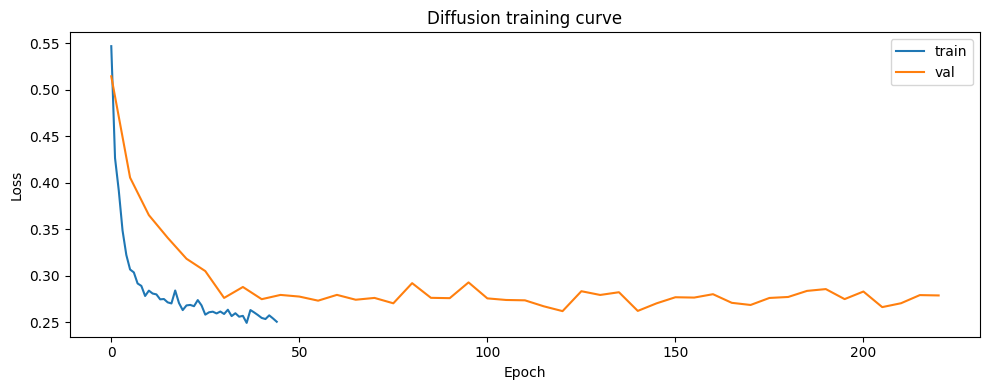

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(trainer.train_losses, label='train')
if trainer.val_losses:
    xs_val = [i * 5 for i in range(len(trainer.val_losses))]
    plt.plot(xs_val, trainer.val_losses, label='val')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.title('Diffusion training curve'); plt.tight_layout(); plt.show()


## 6. Sanity-check panel — all clusters × 4 day/season conditions

Grid: rows = clusters (0–4) · columns = (weekday/weekend) × (winter/summer).
Each panel shows a few validation instances paired with the model's sample
generated for the **same** continuous condition (temp\_normed, log\_mean\_z, log\_std\_z).

* **Same colour** → same meter (real vs model sample share the same query)
* **Solid line** → real profile from that meter on that day
* **Dashed line** → diffusion sample for that meter's condition

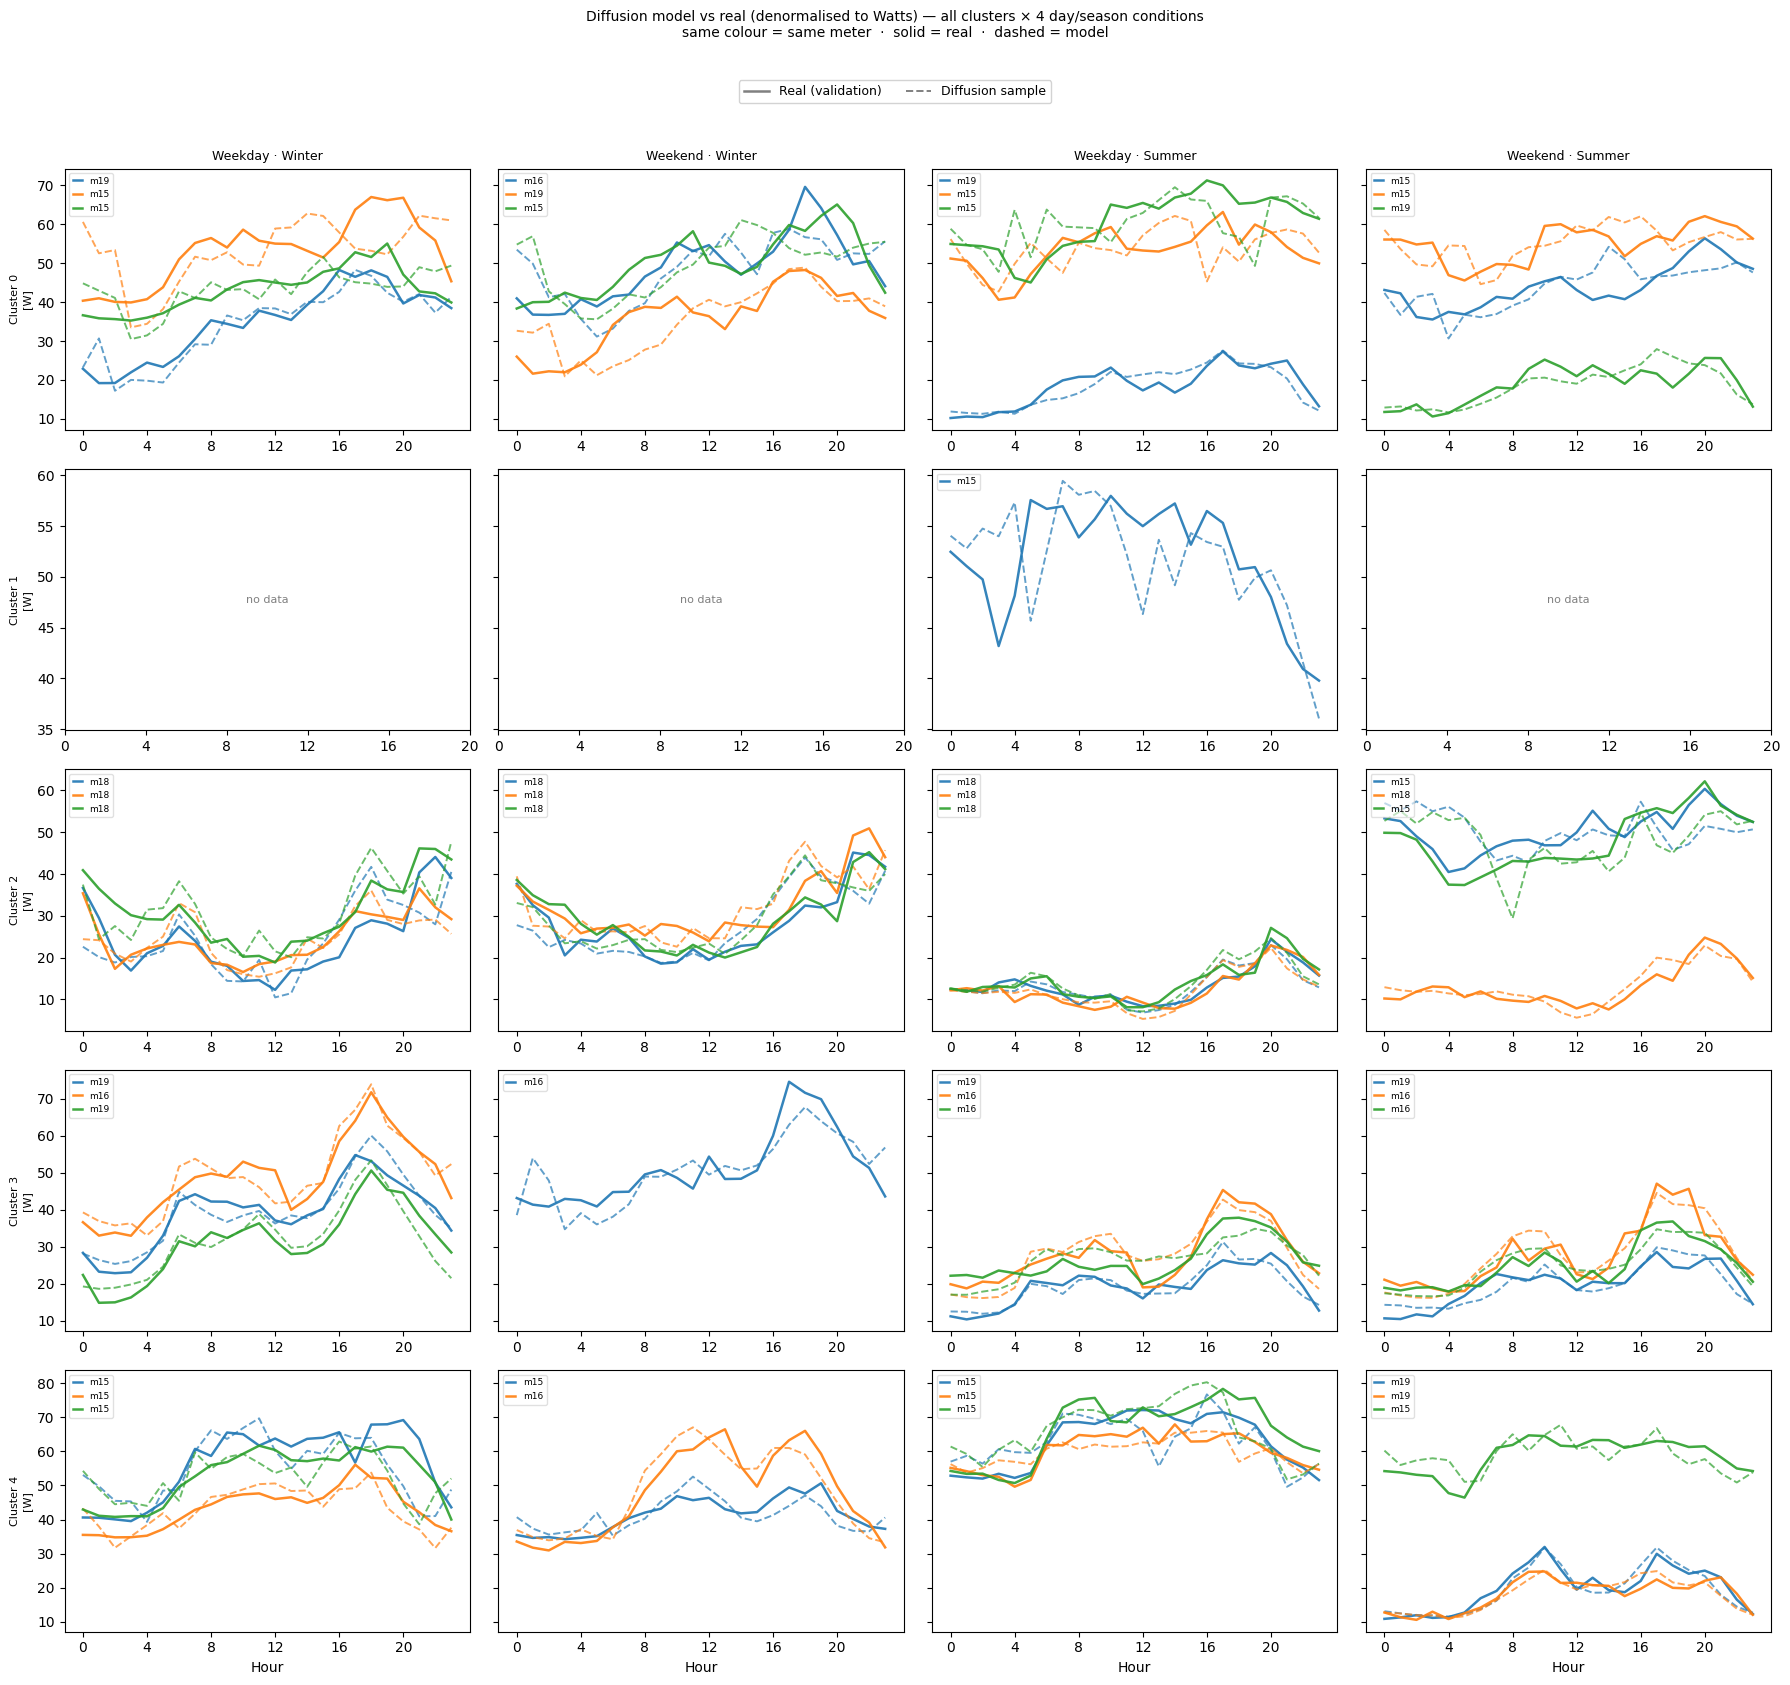

In [ ]:
from matplotlib.lines import Line2D
from src.data.dataset import shape_denormalize

hours    = np.arange(24)
n_sample = 3
key_smp  = jax.random.PRNGKey(123)

day_season_specs = [
    (0, 0, 'Weekday · Winter'),
    (1, 0, 'Weekend · Winter'),
    (0, 2, 'Weekday · Summer'),
    (1, 2, 'Weekend · Summer'),
]

n_rows = N_CLUSTERS
n_cols = len(day_season_specs)
pair_colors = plt.cm.tab10(np.arange(n_sample))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4.5 * n_cols, 3.2 * n_rows),
    sharey='row',
)

for row, cid in enumerate(range(N_CLUSTERS)):
    for col, (dt, season, cond_label) in enumerate(day_season_specs):
        ax = axes[row, col]
        mask = (cd_val[:, 0] == cid) & (cd_val[:, 1] == dt) & (cd_val[:, 2] == season)

        if row == 0:
            ax.set_title(cond_label, fontsize=9)
        if col == 0:
            ax.set_ylabel(f'Cluster {cid}\n[W]', fontsize=8)
        ax.set_xticks(hours[::4])
        if row == n_rows - 1:
            ax.set_xlabel('Hour')

        if not mask.any():
            ax.text(0.5, 0.5, 'no data', transform=ax.transAxes,
                    ha='center', va='center', fontsize=8, color='grey')
            continue

        idx    = np.where(mask)[0]
        chosen = np.random.default_rng(RANDOM_SEED + row * 100 + col).choice(
            idx, size=min(n_sample, len(idx)), replace=False
        )

        # Generate one diffusion sample per chosen instance using its exact cc condition.
        cd_q = jnp.tile(jnp.array([cid, dt, season], dtype=jnp.int32), (len(chosen), 1))
        cc_q = jnp.asarray(cc_val[chosen], dtype=jnp.float32)   # (n_chosen, 3)
        key_smp, sub = jax.random.split(key_smp)
        gen_norm = np.asarray(diffusion.ddim_sample(
            trainer.model, cd_q, cc_q,
            seq_len=24, batch_size=len(chosen), key=sub,
            n_steps=50, guidance_scale=2.0,
        ))

        # Denormalise both real and generated to Watts so the plot is
        # interpretable. Per-instance scales come from the val arrays
        # (real) and from the queried cc rows (generated); by construction
        # they coincide here.
        lm_q, ls_q = invert_scale_z(np.asarray(cc_q[:, 1]),
                                    np.asarray(cc_q[:, 2]), scale_stats)
        real_W = shape_denormalize(x_val[chosen],
                                   log_mean_val[chosen], log_std_val[chosen])
        gen_W  = shape_denormalize(gen_norm, lm_q, ls_q)

        for k, ci in enumerate(chosen):
            mid   = int(mid_val[ci])
            color = pair_colors[k]
            ax.plot(hours, real_W[k],
                    color=color, linewidth=1.8, linestyle='-', alpha=0.9,
                    label=f'm{mid}')
            ax.plot(hours, gen_W[k],
                    color=color, linewidth=1.4, linestyle='--', alpha=0.7,
                    label='_nolegend_')

        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, fontsize=6.5, loc='upper left',
                  framealpha=0.6, ncol=1, handlelength=1.0)

style_legend = [
    Line2D([0], [0], color='grey', linewidth=1.8, linestyle='-',
           label='Real (validation)'),
    Line2D([0], [0], color='grey', linewidth=1.4, linestyle='--',
           label='Diffusion sample'),
]
fig.legend(handles=style_legend, loc='upper center', ncol=2,
           fontsize=9, bbox_to_anchor=(0.5, 1.01), framealpha=0.85)

plt.suptitle(
    'Diffusion model vs real (denormalised to Watts) — all clusters × 4 day/season conditions\n'
    'same colour = same meter  ·  solid = real  ·  dashed = model',
    fontsize=10, y=1.05,
)
plt.tight_layout()
plt.show()


## 7. Save training summary

Dump a small JSON record so downstream notebooks (04, 05) can pick up the
checkpoint along with the conditioning schema, the runtime profile and the
final losses, without having to re-derive them. Same field set across
03a / 03b / 03c → keeps the comparison clean.


In [ ]:
results_dir = pathlib.Path(OUTPUT_DIR) / '03a' / 'results' / 'diffusion'
results_dir.mkdir(parents=True, exist_ok=True)
summary_path = results_dir / 'training_summary.json'

summary = {
    'model'         : 'DiffusionTransformer1D',
    'parametric'    : True,
    'train_instances': int(len(x_tr)),
    'val_instances' : int(len(x_val)),
    'n_clusters'    : int(N_CLUSTERS),
    'gpu_profile'   : bool(GPU),
    'total_steps'   : int(TOTAL_STEPS),
    'n_epochs_cap'  : int(N_EPOCHS),
    'c_discrete'    : ['cluster_id', 'day_type', 'season'],
    'c_continuous'  : ['temp_normed', 'log_mean_z', 'log_std_z'],
    'n_parameters'  : int(params),
    'batch_size'    : BATCH_SIZE,
    'final_train_loss': float(trainer.train_losses[-1]) if trainer.train_losses else None,
    'final_val_loss'  : float(trainer.val_losses[-1])   if trainer.val_losses   else None,
    'random_seed'   : RANDOM_SEED,
    'val_fraction'  : VAL_FRACTION,
}
summary_path.write_text(json.dumps(summary, indent=2))
print(f'Saved → {summary_path}')
print(json.dumps(summary, indent=2))


Saved → /content/tesina/output/03a/results/diffusion/training_summary.json
{
  "model": "DiffusionTransformer1D",
  "parametric": true,
  "train_instances": 7440,
  "val_instances": 1488,
  "n_clusters": 5,
  "gpu_profile": true,
  "total_steps": 5800,
  "n_epochs_cap": 100,
  "c_discrete": [
    "cluster_id",
    "day_type",
    "season"
  ],
  "c_continuous": [
    "temp_normed",
    "log_mean_z",
    "log_std_z"
  ],
  "n_parameters": 1106274,
  "batch_size": 128,
  "final_train_loss": 0.2503624861610347,
  "final_val_loss": 0.278644584864378,
  "random_seed": 42,
  "val_fraction": 0.15
}


In [ ]:
# === Sync GPU results back to local repo via GitHub (Colab only) ===========
# Commits training results + checkpoint and pushes to GitHub.
# Requires a GitHub PAT stored as a Colab Secret named  GITHUB_TOKEN
# (Menu → Secrets → Add new secret → Name: GITHUB_TOKEN → Value: ghp_...).
import pathlib, subprocess

def _in_colab():
    try:
        import google.colab; return True
    except ImportError:
        return False

if _in_colab():
    REPO = pathlib.Path("/content/tesina")
    to_sync = [
        "output/03a/results/diffusion/training_summary.json",
        "output/03a/checkpoints/best_model.pkl",
    ]
    subprocess.run(["git", "-C", str(REPO), "config", "user.email", "colab@run.local"], check=False)
    subprocess.run(["git", "-C", str(REPO), "config", "user.name",  "Colab GPU run"],   check=False)
    for f in to_sync:
        subprocess.run(["git", "-C", str(REPO), "add", "-f", f], check=False)
    r = subprocess.run(["git", "-C", str(REPO), "commit", "-m", "results: 03a GPU training run"],
                       capture_output=True, text=True)
    print(r.stdout.strip() or r.stderr.strip())

    # Try Colab Secrets for the GitHub token (safe — never printed)
    try:
        from google.colab import userdata
        token = userdata.get("GITHUB_TOKEN")
        remote = subprocess.run(["git", "-C", str(REPO), "remote", "get-url", "origin"],
                                capture_output=True, text=True).stdout.strip()
        if "github.com" in remote and not remote.startswith("https://ghp_"):
            authed = remote.replace("https://", f"https://{token}@")
            subprocess.run(["git", "-C", str(REPO), "remote", "set-url", "origin", authed], check=False)
    except Exception:
        token = None  # no secret configured

    p = subprocess.run(["git", "-C", str(REPO), "push"], capture_output=True, text=True)
    if p.returncode == 0:
        print("Pushed — run  git pull  locally to retrieve the results.")
    else:
        print("Push failed. Options:")
        print("  A) Add a GitHub PAT as a Colab Secret named GITHUB_TOKEN and re-run this cell.")
        print("  B) Download files manually from the Colab file panel:")
        for f in to_sync:
            print(f"       /content/tesina/{f}")
else:
    print("Local run — results already in place.")


On branch master
Your branch is ahead of 'origin/master' by 1 commit.
  (use "git push" to publish your local commits)

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	output/03a/checkpoints/ckpt_epoch0010.pk
	output/03a/checkpoints/ckpt_epoch0020.pk
	output/03a/checkpoints/ckpt_epoch0030.pk
	output/03a/checkpoints/ckpt_epoch0040.pk

nothing added to commit but untracked files present (use "git add" to track)
Push failed. Options:
  A) Add a GitHub PAT as a Colab Secret named GITHUB_TOKEN and re-run this cell.
  B) Download files manually from the Colab file panel:
       /content/tesina/output/03a/results/diffusion/training_summary.json
       /content/tesina/output/03a/checkpoints/best_model.pkl
